In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.spatial.distance import euclidean
from wordcloud import WordCloud
from gensim.parsing.preprocessing import STOPWORDS
import pandas as pd


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

pl.Config.set_tbl_rows(10)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(50)

polars.config.Config

In [2]:
yelp_stopwords = [
    "ive", "im", "us", "got", "went", "came",
    "also", "even", "really", "just", "would",
    "always", "much", "one", "get", "go", "back"
]
stopwords_list = list(STOPWORDS) + [""] + yelp_stopwords

nrc_scores_path = "../results/sentiment_analysis/yelp_academic_dataset_review_scored.csv"
topics_dir      = "../results/topic_modeling/"
categories      = ["burgers", "fast_food", "mexican", "pubs", "steakhouses"]
topic_files     = {cat: os.path.join(topics_dir, f"yelp_topics_{cat}.csv") for cat in categories}
nrc_emotions    = [
    'nrc_anger', 'nrc_anticipation', 'nrc_disgust', 'nrc_fear',
    'nrc_joy', 'nrc_sadness', 'nrc_surprise', 'nrc_trust'
]


def cargar_datos_emociones(nrc_scores_path: str, topic_files: dict[str, str], categories: list[str], nrc_emotions: list[str]):
    """
    Carga las puntuaciones NRC y las une con los tópicos BERTopic y LDA por categoría.

    Args:
        nrc_scores_path (str):  Ruta al CSV con puntuaciones NRC de sentimiento.
        topic_files (dict):     Diccionario categoría -> ruta al CSV de tópicos.
        categories (list):      Lista de categorías a procesar.
        nrc_emotions (list):    Columnas de emociones NRC a seleccionar.
    """
    nrc_lazy = pl.scan_csv(nrc_scores_path).select(['review_id'] + nrc_emotions)

    category_dfs = {}
    for cat in categories:
        print(f"Procesando categoría: {cat}...")

        topic_lazy = pl.scan_csv(topic_files[cat]).select(
            ['review_id', 'bertopic_dominant_topic', 'lda_dominant_topic']
        )

        category_dfs[cat] = (
            topic_lazy
            .join(nrc_lazy, on="review_id", how="left")
            .collect()
        )

    print("Reviews por categoría procesadas junto con sus sentiment scores.")
    return category_dfs


category_dfs = cargar_datos_emociones(nrc_scores_path, topic_files, categories, nrc_emotions)

Procesando categoría: burgers...
Procesando categoría: fast_food...
Procesando categoría: mexican...
Procesando categoría: pubs...
Procesando categoría: steakhouses...
Reviews por categoría procesadas junto con sus sentiment scores.


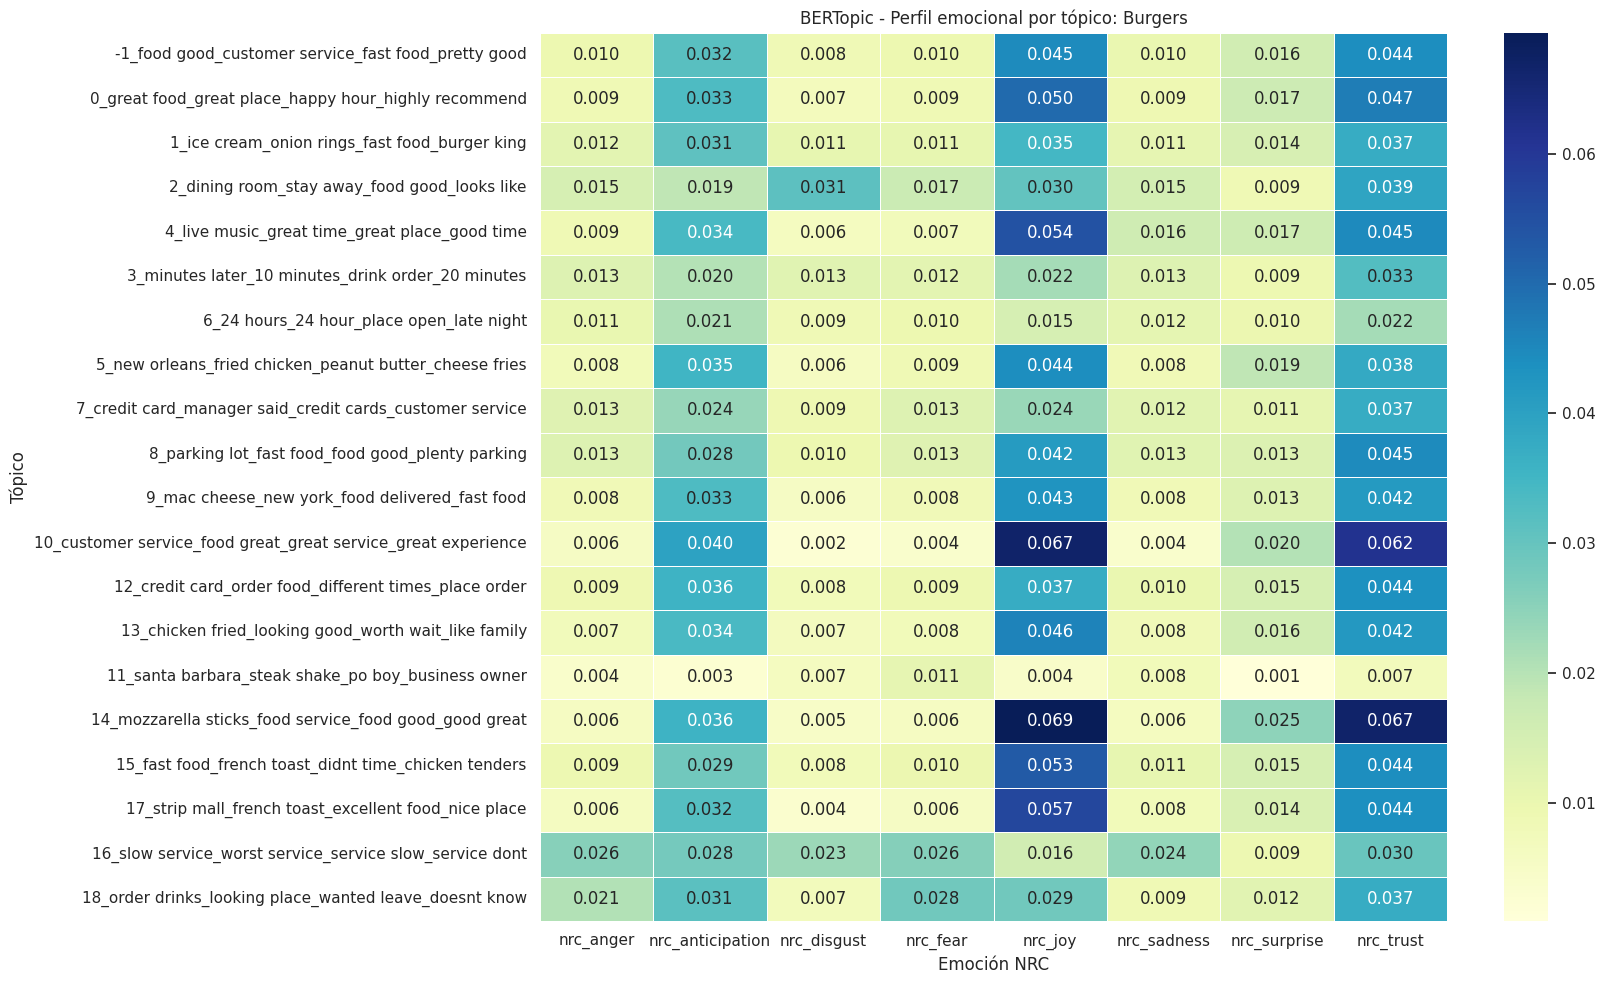

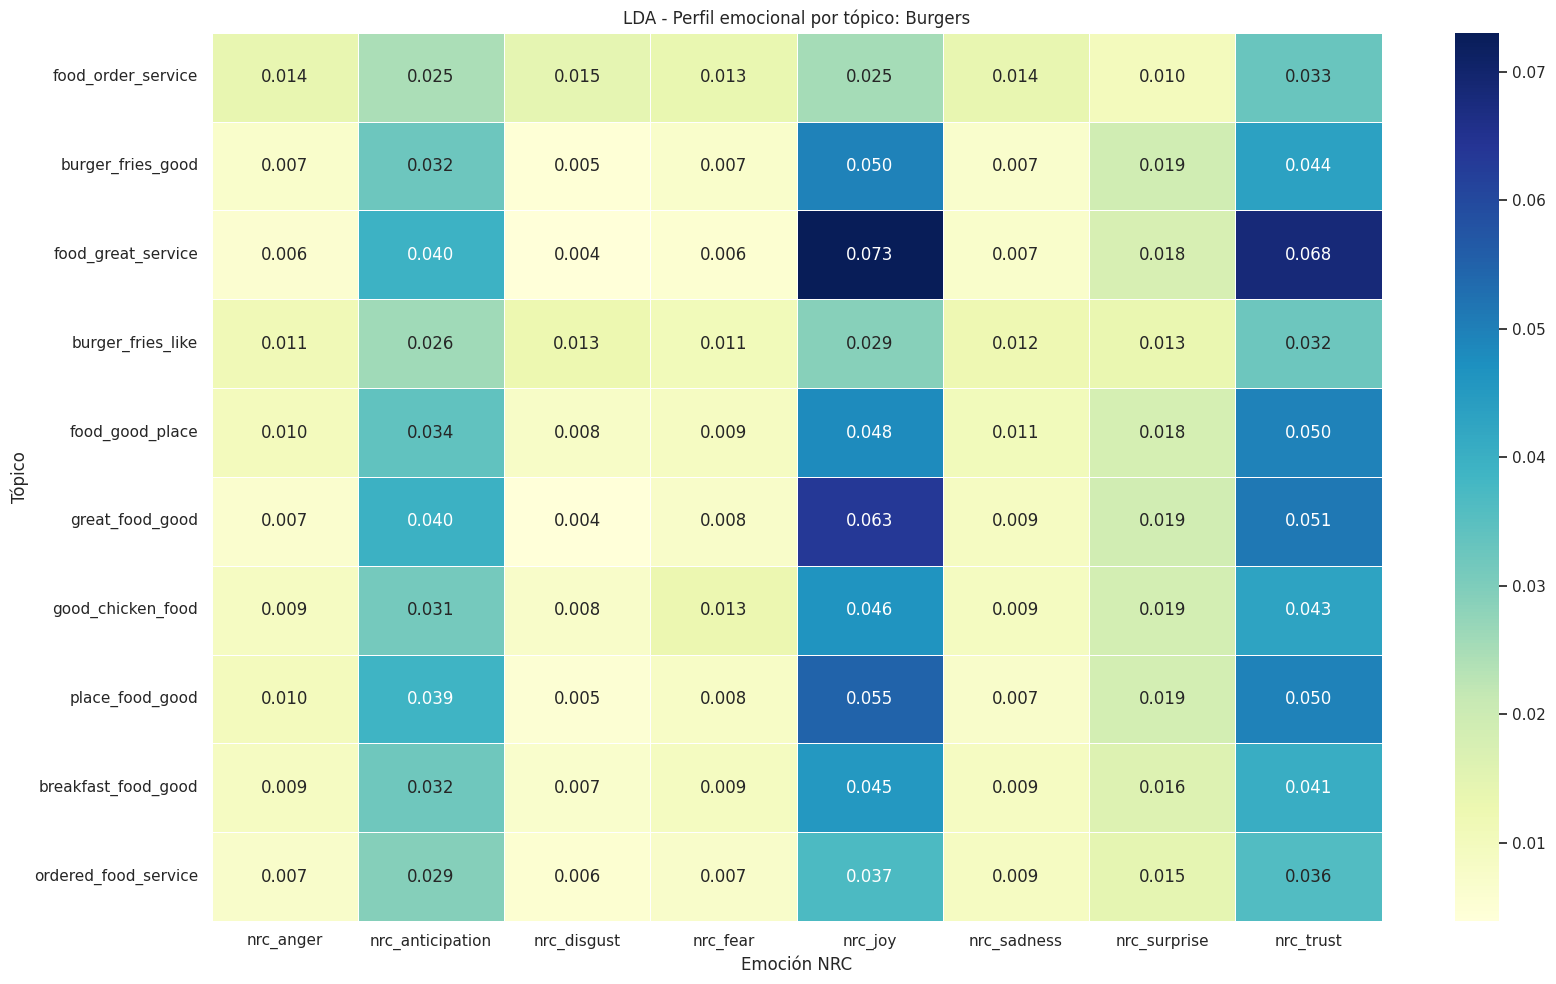

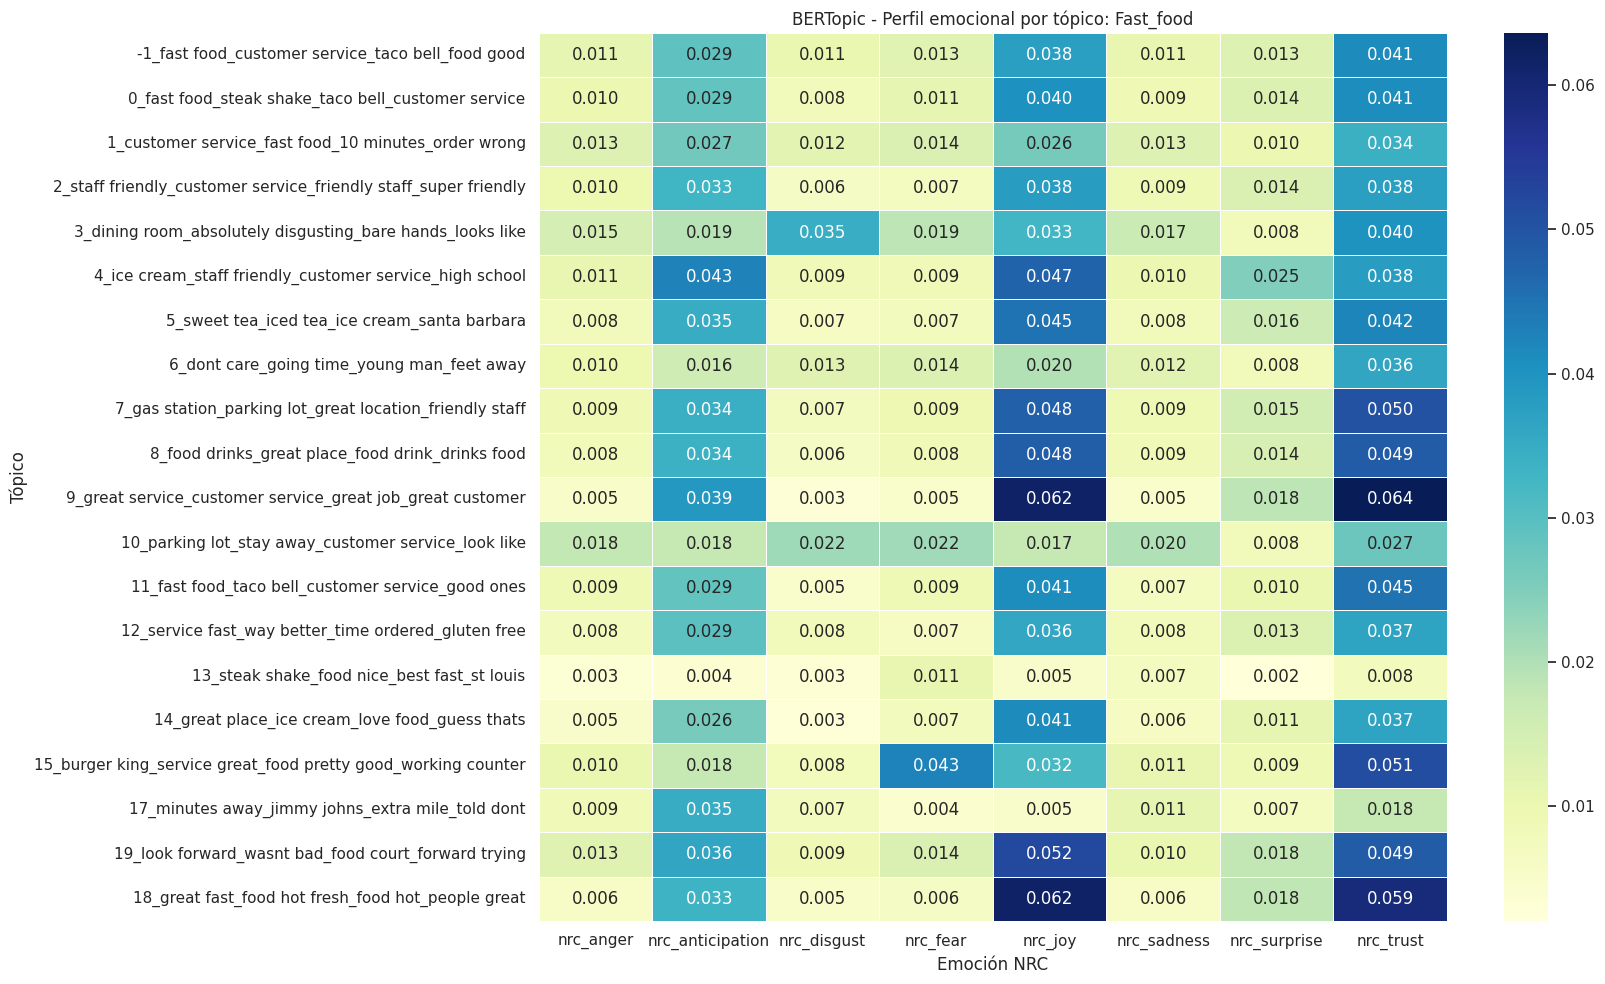

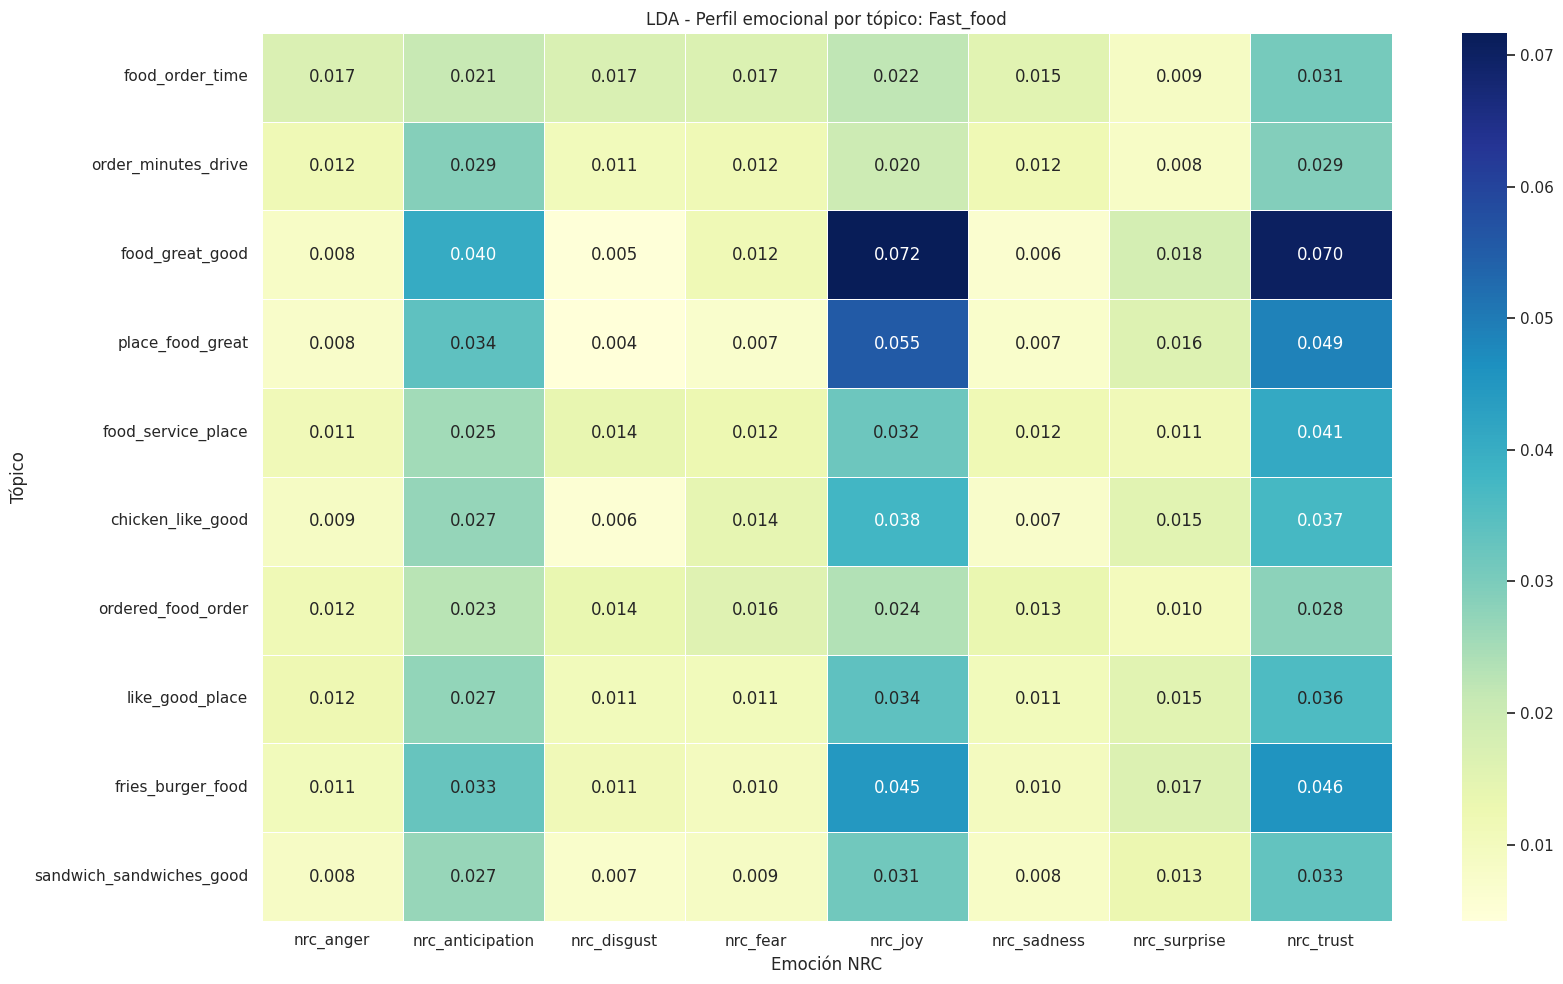

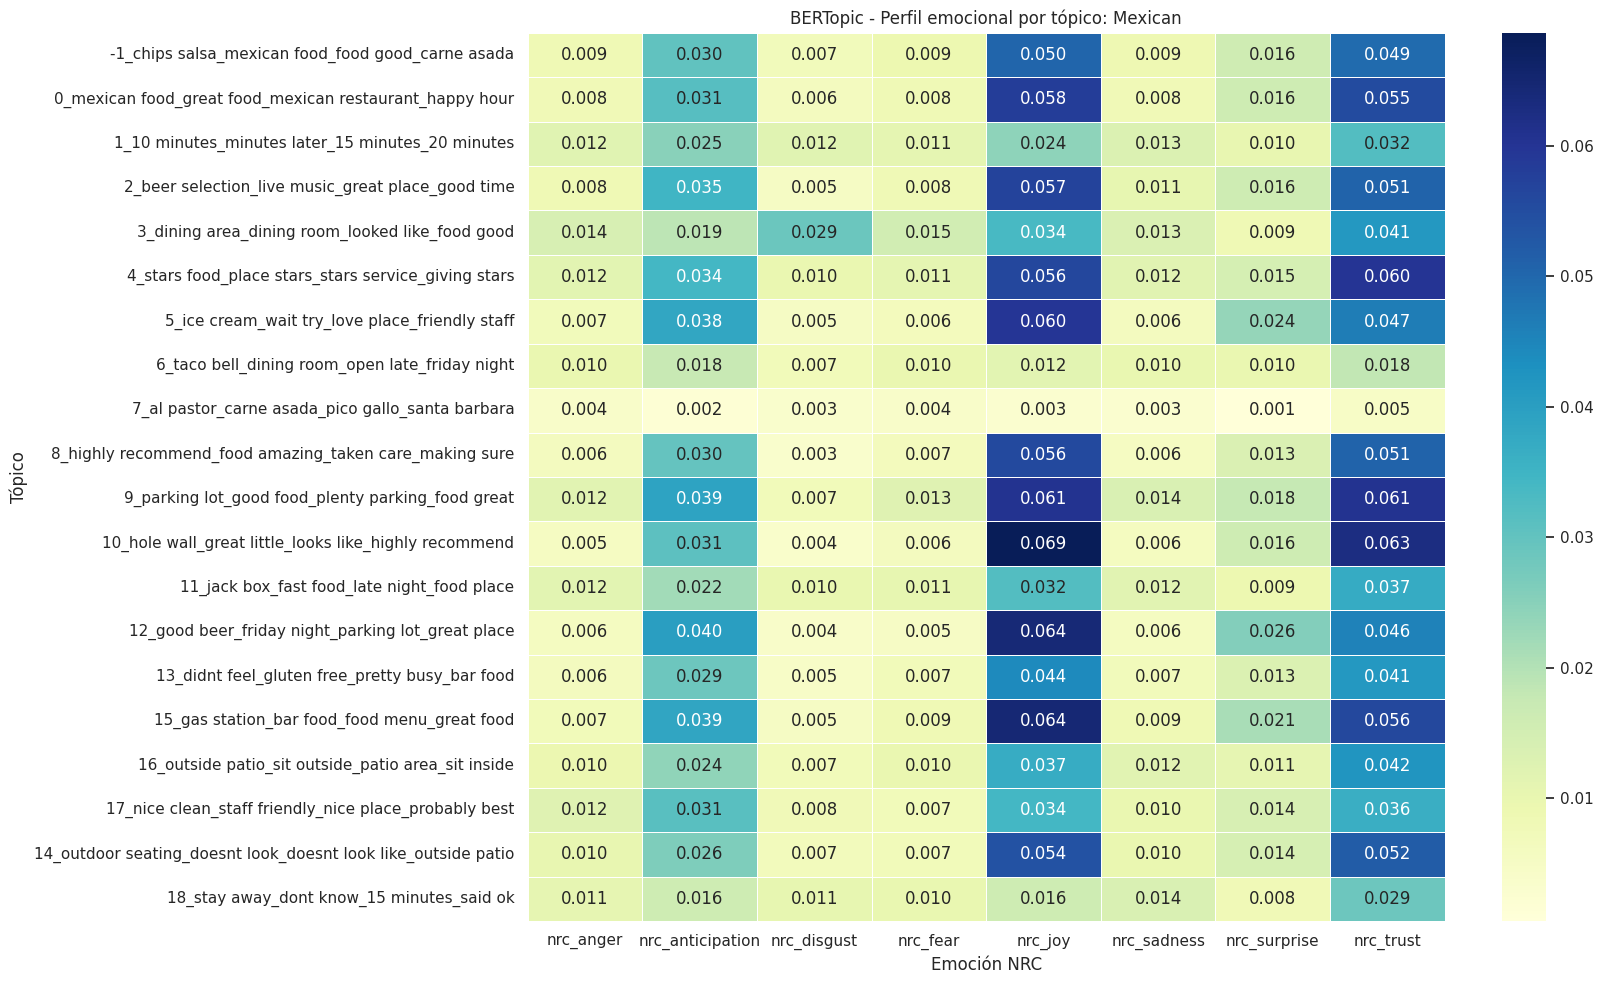

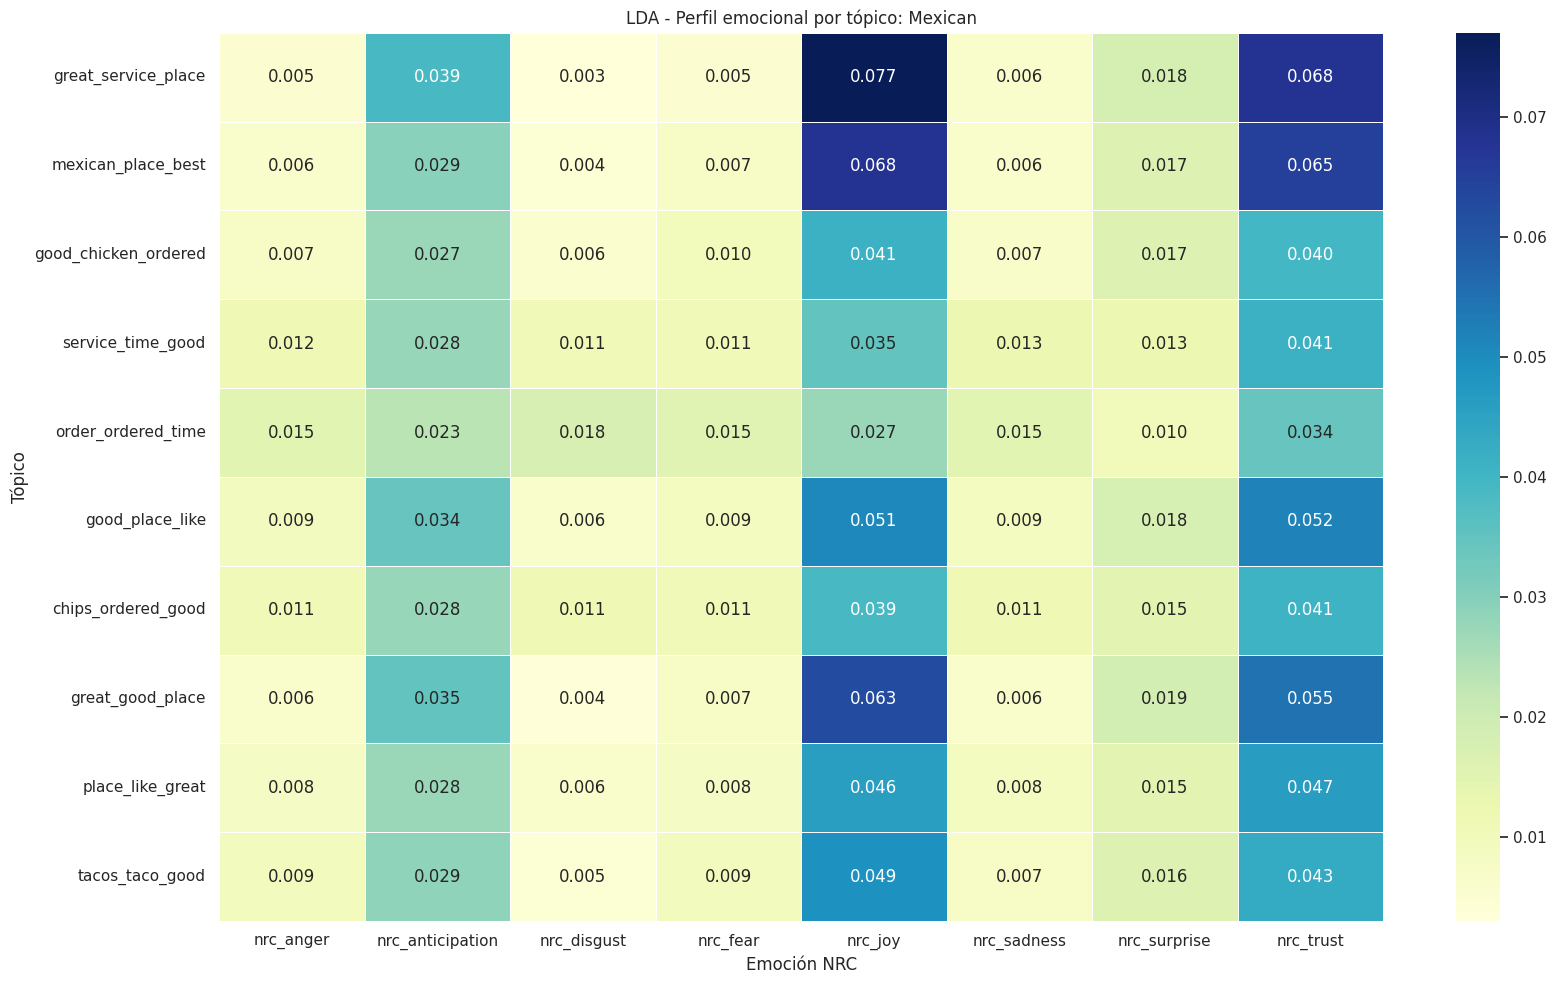

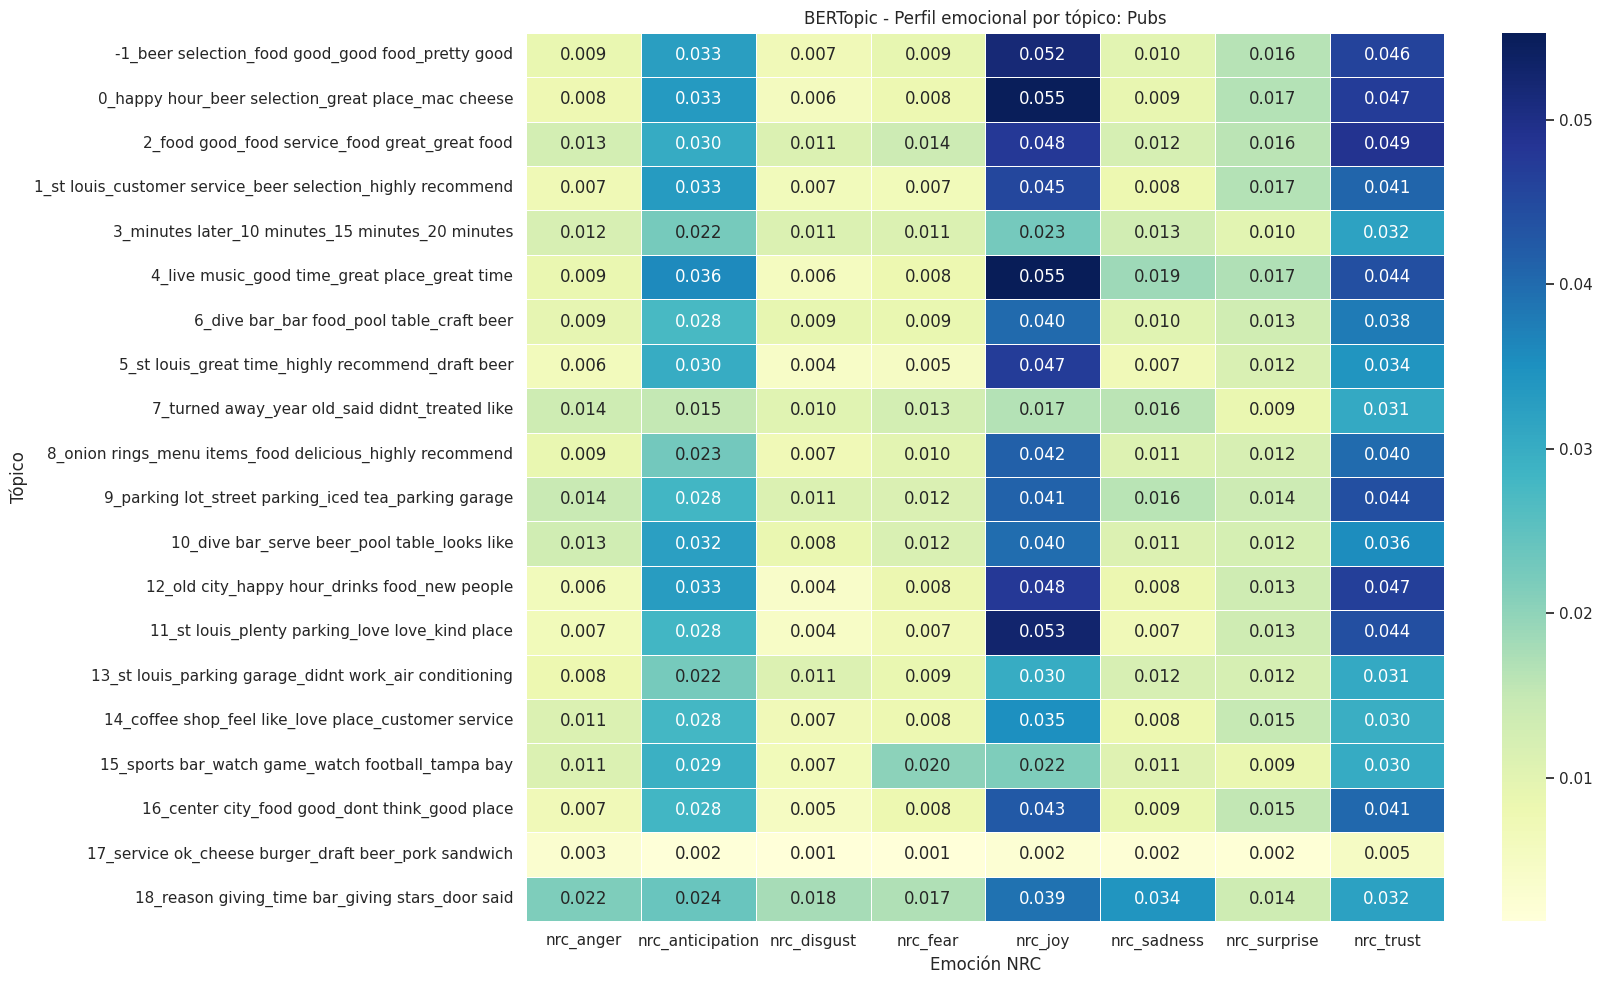

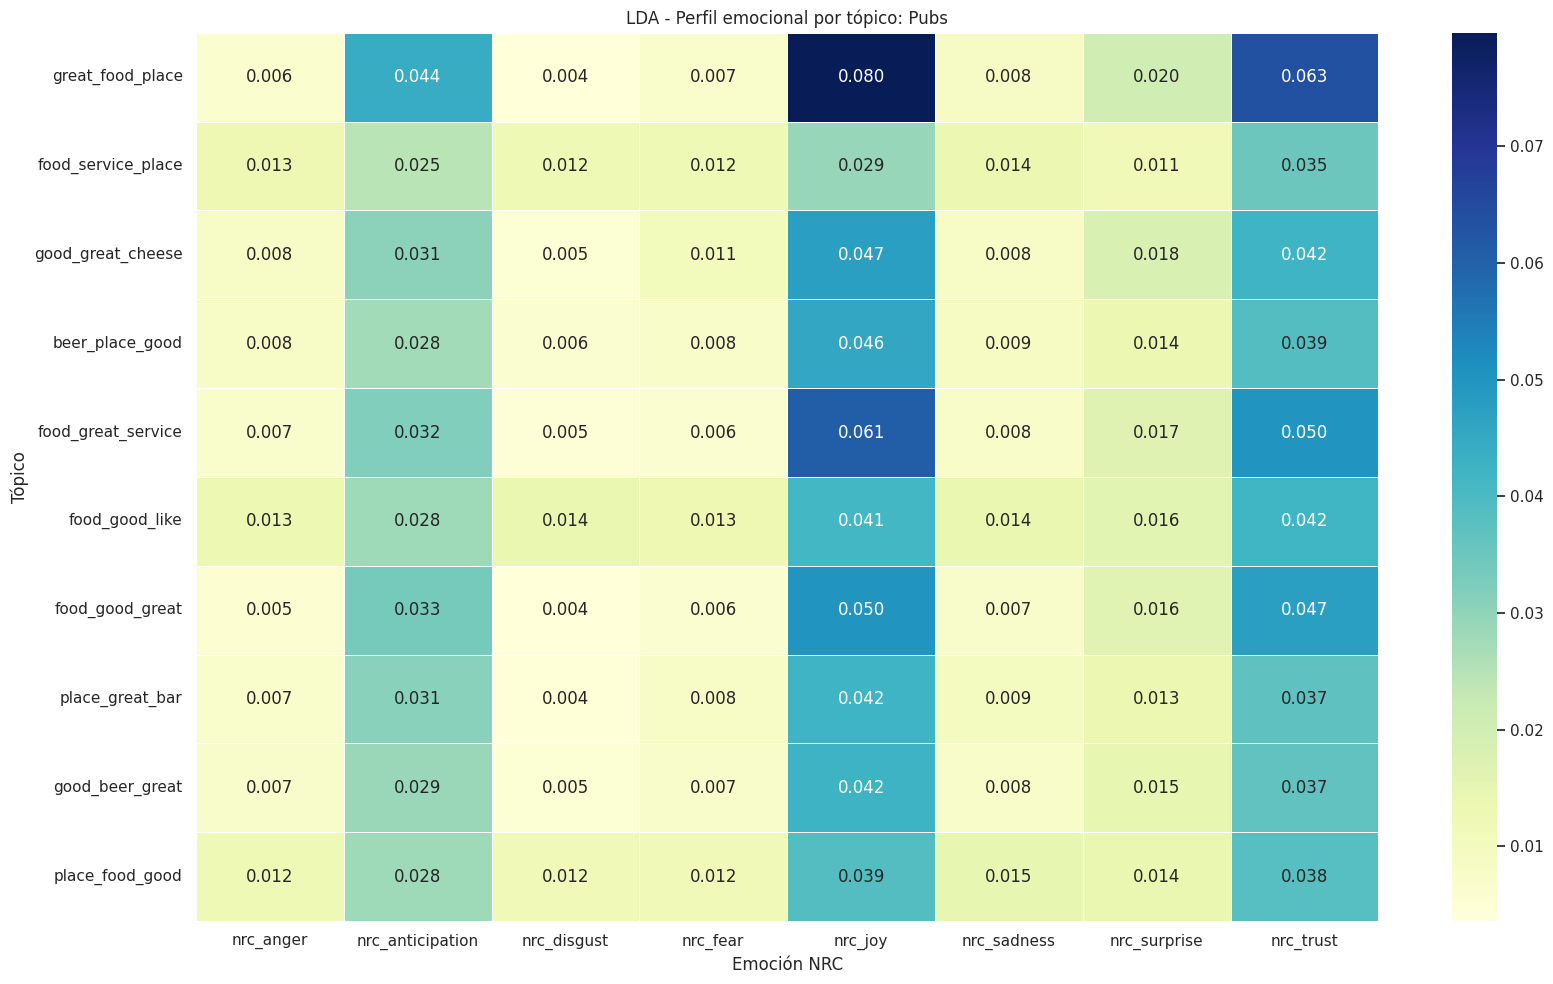

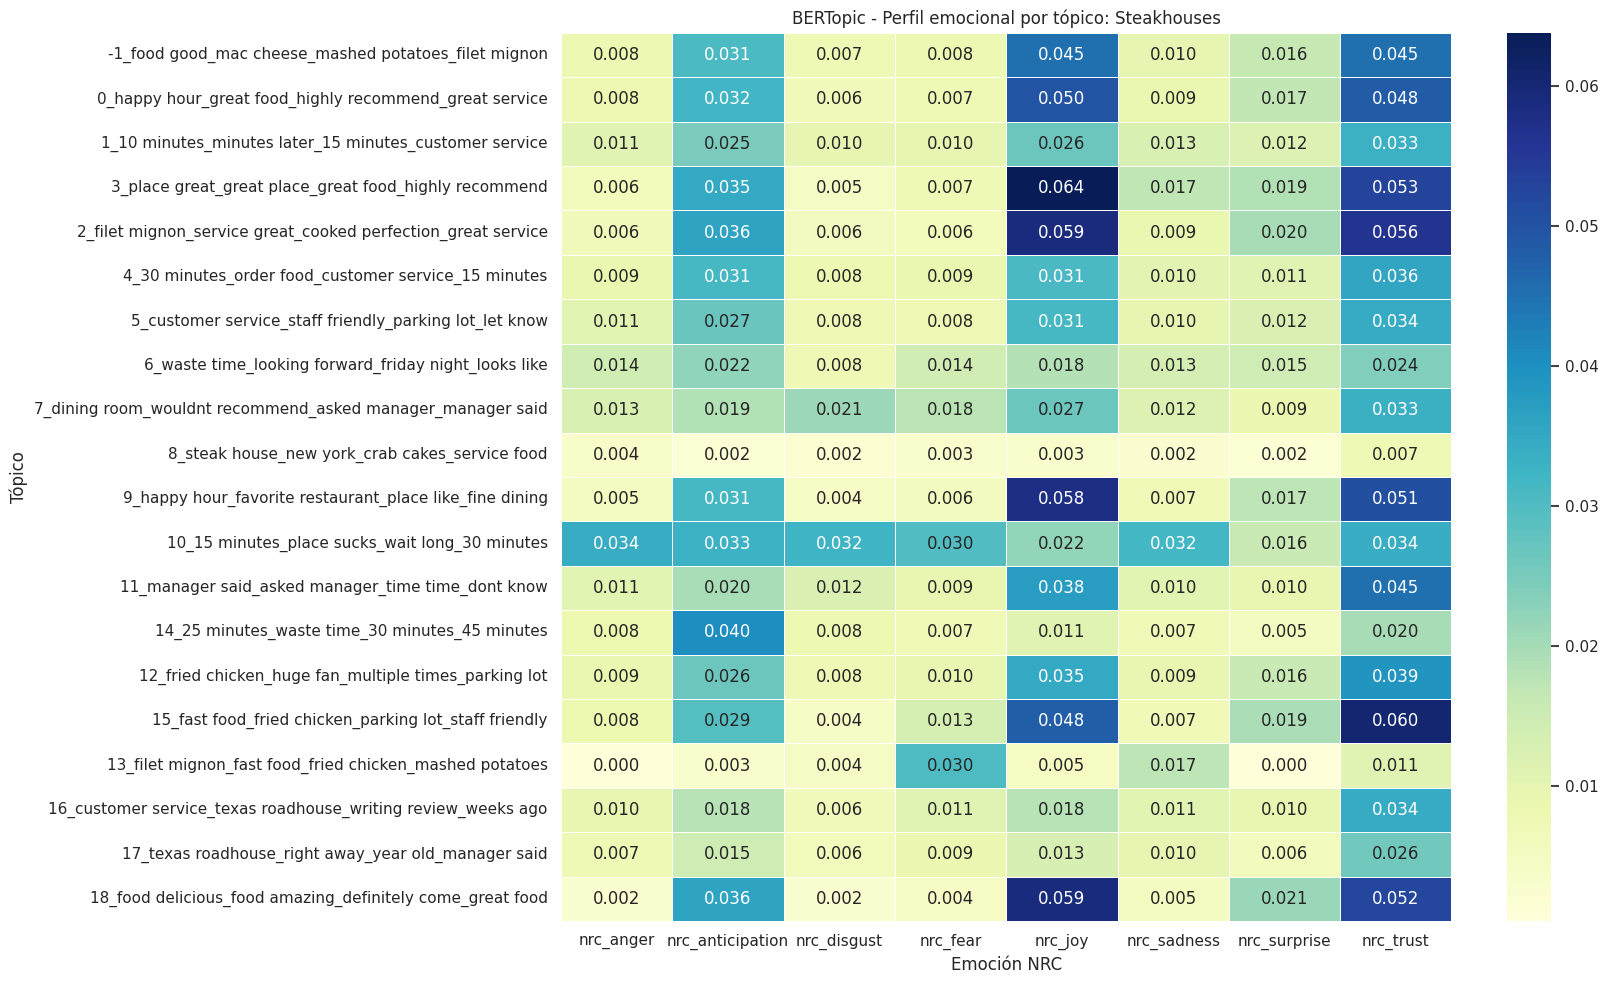

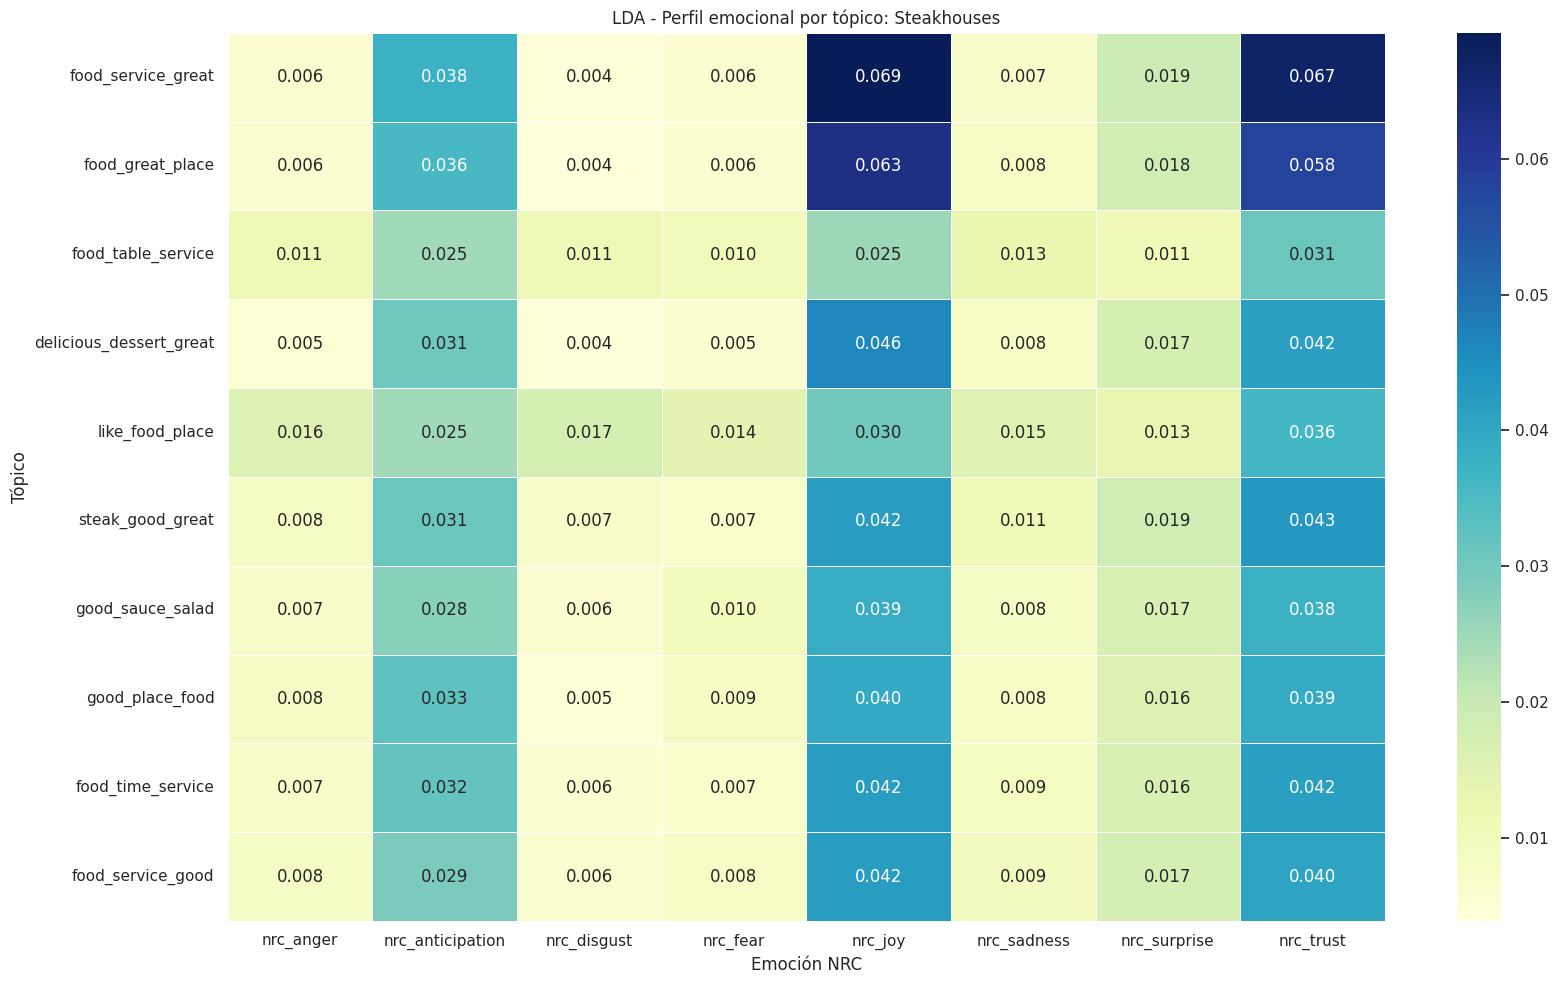

UnboundLocalError: cannot access local variable 'reviews' where it is not associated with a value

In [3]:
def plot_emotion_heatmap(df: pl.DataFrame, group_col: str, title_prefix: str, nrc_emotions: list[str], top_n_topics: int = 20):
    """
    Genera un heatmap del perfil emocional medio por tópico.

    Args:
        df (pl.DataFrame):    DataFrame con columnas de tópico y emociones NRC.
        group_col (str):      Columna de agrupación (tópico BERTopic o LDA).
        title_prefix (str):   Título del gráfico.
        nrc_emotions (list):  Lista de emociones NRC a representar.
        top_n_topics (int):   Número máximo de tópicos a mostrar (default: 20).
    """
    agg_exprs = [pl.col(emo).mean().alias(emo) for emo in nrc_emotions]
    agg_exprs.append(pl.len().alias("n_reviews"))

    pd_df = (
        df.group_by(group_col)
        .agg(agg_exprs)
        .drop_nulls(subset=[group_col])
        .to_pandas()
        .set_index(group_col)
        .sort_values("n_reviews", ascending=False)
        .head(top_n_topics)
        .drop(columns=["n_reviews"])
    )

    plt.figure(figsize=(17, 10))
    sns.heatmap(pd_df, cmap="YlGnBu", annot=True, fmt=".3f", linewidths=.5)
    plt.title(title_prefix)
    plt.ylabel("Tópico")
    plt.xlabel("Emoción NRC")
    plt.tight_layout()
    plt.show()


def plot_emotion_heatmaps_all(category_dfs: dict[str, pl.DataFrame], categories: list[str], nrc_emotions: list[str]):
    """
    Genera heatmaps de perfil emocional para BERTopic y LDA en todas las categorías.

    Args:
        category_dfs (dict):  Diccionario categoría -> DataFrame.
        categories (list):    Lista de categorías a procesar.
        nrc_emotions (list):  Lista de emociones NRC a representar.
    """
    for cat in categories:
        plot_emotion_heatmap(
            category_dfs[cat],
            "bertopic_dominant_topic",
            f"BERTopic - Perfil emocional por tópico: {cat.capitalize()}",
            nrc_emotions,
        )
        plot_emotion_heatmap(
            category_dfs[cat],
            "lda_dominant_topic",
            f"LDA - Perfil emocional por tópico: {cat.capitalize()}",
            nrc_emotions,
        )


def get_topic_texts(cat: str, topic_name: str, topic_files: dict[str, str]):
    """
    Recupera los textos de reseñas de un tópico BERTopic concreto.

    Args:
        cat (str):           Categoría a consultar.
        topic_name (str):    Nombre del tópico a filtrar.
        topic_files (dict):  Diccionario categoría -> ruta al CSV de tópicos.

    Returns:
        list[str]: Lista de textos de reseñas del tópico.
    """
    return (
        pl.scan_csv(topic_files[cat])
        .filter(pl.col("bertopic_dominant_topic") == topic_name)
        .select("text")
        .collect()
        .to_series()
        .to_list()
    )


def plot_topic_wordcloud(cat: str, topic_name: str, title: str, topic_files: dict[str, str], stopwords_list: list[str]):
    """
    Genera un WordCloud con las reseñas de un tópico BERTopic.

    Args:
        cat (str):              Categoría a consultar.
        topic_name (str):       Nombre del tópico a representar.
        title (str):            Título del gráfico.
        topic_files (dict):     Diccionario categoría -> ruta al CSV de tópicos.
        stopwords_list (list):  Stopwords a excluir del WordCloud.
    """
    topic_reviews = get_topic_texts(cat, topic_name, topic_files)

    if not topic_reviews:
        print(f"⚠ No se encontraron reviews para el tópico: {topic_name}")
        return

    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        stopwords=set(stopwords_list),
        max_words=80,
        colormap="Blues",
    ).generate(" ".join(topic_reviews))

    plt.figure(figsize=(10, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def sample_topic_reviews(cat: str, topic_col: str, topic_name: str, topic_files: dict[str, str], n: int = 10):
    """
    Muestra una muestra aleatoria de reseñas de un tópico concreto.

    Args:
        cat (str):           Categoría a consultar.
        topic_col (str):     Columna de tópico a filtrar (BERTopic o LDA).
        topic_name (str):    Nombre del tópico a filtrar.
        topic_files (dict):  Diccionario categoría -> ruta al CSV de tópicos.
        n (int):             Número máximo de reseñas a mostrar (default: 10).
    """
    reviews = (
        pl.scan_csv(topic_files[cat])
        .filter(pl.col(topic_col) == topic_name)
        .select(["stars", "text"])
        .collect()
        .sample(n=min(n, len(reviews)), seed=42)
    )

    print(f"\n{'='*60}")
    print(f"Tópico: {topic_name} | Categoría: {cat}")
    print(f"{'='*60}")
    for row in reviews.iter_rows(named=True):
        print(f"\n{row['stars']} stars | {row['text'][:300]}...")
        print("-" * 60)


def explorar_topicos_interesantes(interesting_topics: dict[str, dict[str, list[str]]], topic_files: dict[str, str] ,n: int = 10):
    """
    Itera sobre los tópicos de interés definidos manualmente y muestra
    muestras de reseñas para cada uno.

    Args:
        interesting_topics (dict): Estructura {cat: {"bertopic": [...], "lda": [...]}}.
        topic_files (dict):        Diccionario categoría -> ruta al CSV de tópicos.
        n (int):                   Número de reseñas a mostrar por tópico (default: 10).
    """
    for cat, models in interesting_topics.items():
        for model_type, topics in models.items():
            # Determinar la columna de tópico según el modelo
            topic_col = "bertopic_dominant_topic" if model_type == "bertopic" else "lda_dominant_topic"
            for topic in topics:
                sample_topic_reviews(cat, topic_col, topic, topic_files, n=n)



interesting_topics = {
    "burgers":     {"bertopic": ["14_yelp reviews_yelp review_reviews yelp_yelp app",
                                 "3_best bartender_beer selection_neighborhood bar_best bartenders"],
                    "lda":      ["order_minutes_asked", "ordered_dont_know"]},
    "fast_food":   {"bertopic": ["8_zero stars_negative stars_deserve star_zero star",
                                 "1_worst mcdonalds_big mac_mcdonalds location_best mcdonalds",
                                 "6_says open_doors locked_24 hours_open till"],
                    "lda":      ["dont_eat_fries", "dont_manager_customer"]},
    "mexican":     {"bertopic": ["12_yelp reviews_yelp_review_reviews_yelp_based yelp",
                                 "18_authentic mexican_mexican authentic_best authentic mexican_looking authentic"],
                    "lda":      ["tacos_mexican_best", "order_dont_said", "ordered_minutes_order"]},
    "pubs":        {"bertopic": ["4_staff friendly_friendly staff_bad meal_love love"],
                    "lda":      ["minutes_table_bar"]},
    "steakhouses": {"bertopic": ["14_pats genos_genos pats_better pats_cheese steak",
                                 "12_birthday dinner_celebrated birthday_happy birthday_celebrate birthday"],
                    "lda":      ["dinner_sushi_price", "better_dont_steak", "table_asked_minutes"]},
}

plot_emotion_heatmaps_all(category_dfs, categories, nrc_emotions)
explorar_topicos_interesantes(interesting_topics, topic_files)


[Burgers]
  Top outlier BERTopic : '26_dont eat_cash register_burger king_shift change' (dist=0.1082)
  Top outlier LDA      : 'food_great_service' (dist=0.0380)



[Fast_food]
  Top outlier BERTopic : '13_steak shake_food nice_best fast_st louis' (dist=0.0551)
  Top outlier LDA      : 'food_great_good' (dist=0.0474)



[Mexican]
  Top outlier BERTopic : '7_al pastor_carne asada_pico gallo_santa barbara' (dist=0.0756)
  Top outlier LDA      : 'order_ordered_time' (dist=0.0350)



[Pubs]
  Top outlier BERTopic : '27_horrible service_service terrible_busy service_prices high' (dist=0.0930)
  Top outlier LDA      : 'great_food_place' (dist=0.0349)



[Steakhouses]
  Top outlier BERTopic : '28_friendly service_food service_love food_great food' (dist=0.0885)
  Top outlier LDA      : 'food_service_great' (dist=0.0323)




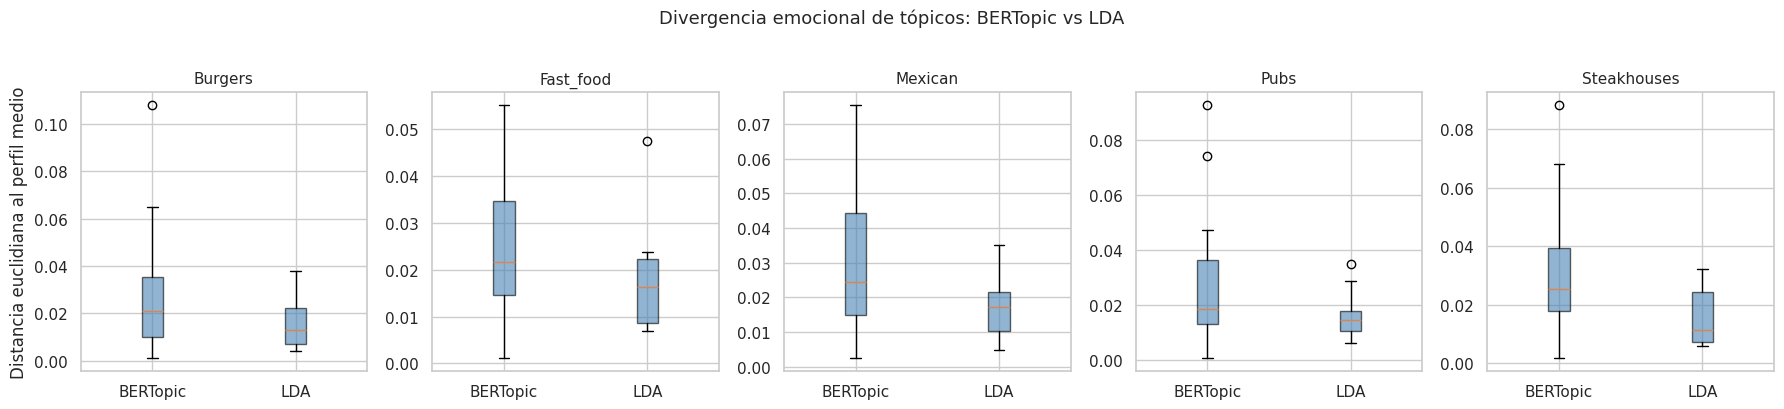

,Categoría,Top outlier BERTopic,Dist. BERTopic,Emoción dominante,Top outlier LDA,Dist. LDA,Emoción dominante
0,Burgers,26_dont eat_cash register_burger king_shift ch...,0.1082,disgust,food_great_service,0.0380,joy
1,Fast_food,13_steak shake_food nice_best fast_st louis,0.0551,fear,food_great_good,0.0474,joy
2,Mexican,7_al pastor_carne asada_pico gallo_santa barbara,0.0756,trust,order_ordered_time,0.0350,trust
3,Pubs,27_horrible service_service terrible_busy serv...,0.0930,disgust,great_food_place,0.0349,joy
4,Steakhouses,28_friendly service_food service_love food_gre...,0.0885,joy,food_service_great,0.0323,joy


In [4]:
def analyze_emotional_outliers(categories, category_dfs, nrc_emotions):
    """
    Calcula y visualiza la divergencia emocional (outliers) de los tópicos generados
    por BERTopic y LDA con respecto al perfil emocional medio de cada categoría.

    Args:
        categories (list<str>): Lista con los nombres de las categorías a analizar.
        category_dfs (dict): Diccionario donde las claves son los nombres de las categorías y los valores son Polars DataFrames que contienen las columnas de emociones y tópicos.
        nrc_emotions (list<str>): Lista con los nombres de las columnas que representan las emociones de NRC.
    """
    def find_emotional_outliers(df, group_col, category_name):
        """
        Encuentra y ordena los tópicos según su distancia euclidiana al perfil 
        emocional medio de la categoría.

        Args:
            df (DataFrame): DataFrame de Polars con los datos de la categoría.
            group_col (str): Nombre de la columna de agrupación de tópicos.
            category_name (str): Nombre de la categoría.
        """
        cat_mean = df.select([pl.col(emo).mean() for emo in nrc_emotions]).to_numpy()[0]
        
        topic_profiles = df.group_by(group_col).agg([
            pl.col(emo).mean() for emo in nrc_emotions
        ]).drop_nulls(subset=[group_col])
        
        topic_pd = topic_profiles.to_pandas()
        features = topic_pd[nrc_emotions].values
        topic_pd['distancia_euclidiana'] = [euclidean(f, cat_mean) for f in features]
        
        return topic_pd.sort_values(by='distancia_euclidiana', ascending=False)

    outliers_dict = {}

    for cat in categories:
        df = category_dfs[cat]
        
        bert_outliers = find_emotional_outliers(df, "bertopic_dominant_topic", cat.capitalize())
        lda_outliers  = find_emotional_outliers(df, "lda_dominant_topic",      cat.capitalize())
        
        outliers_dict[cat] = {"bertopic": bert_outliers, "lda": lda_outliers}
        
        print(f"\n[{cat.capitalize()}]")
        print(f"  Top outlier BERTopic : '{bert_outliers.iloc[0]['bertopic_dominant_topic']}' (dist={bert_outliers.iloc[0]['distancia_euclidiana']:.4f})")
        print(f"  Top outlier LDA      : '{lda_outliers.iloc[0]['lda_dominant_topic']}' (dist={lda_outliers.iloc[0]['distancia_euclidiana']:.4f})")
        print("\n")
        
    fig, axes = plt.subplots(1, len(categories), figsize=(18, 4), sharey=False)
    
    # Manejo de seguridad en caso de que solo haya 1 categoría (axes no sería un array)
    if len(categories) == 1:
        axes = [axes]

    for i, cat in enumerate(categories):
        bert_dists = outliers_dict[cat]["bertopic"]["distancia_euclidiana"].values
        lda_dists  = outliers_dict[cat]["lda"]["distancia_euclidiana"].values
        
        axes[i].boxplot(
            [bert_dists, lda_dists],
            tick_labels=["BERTopic", "LDA"],
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6),
        )
        axes[i].set_title(cat.capitalize(), fontsize=11)
        axes[i].set_ylabel("Distancia euclidiana al perfil medio" if i == 0 else "")
        axes[i].tick_params(axis='x', rotation=0)

    plt.suptitle("Divergencia emocional de tópicos: BERTopic vs LDA", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    rows = []
    for cat in categories:
        bert_top = outliers_dict[cat]["bertopic"].iloc[0]
        lda_top  = outliers_dict[cat]["lda"].iloc[0]
        
        # Emoción dominante = la de mayor valor en el perfil del outlier
        bert_dominant_emo = max(nrc_emotions, key=lambda e: bert_top[e])
        lda_dominant_emo  = max(nrc_emotions, key=lambda e: lda_top[e])
        
        rows.append({
            "Categoría":           cat.capitalize(),
            "Top outlier BERTopic": bert_top["bertopic_dominant_topic"],
            "Dist. BERTopic":      round(bert_top["distancia_euclidiana"], 4),
            "Emoción dominante":   bert_dominant_emo.replace("nrc_", ""),
            "Top outlier LDA":     lda_top["lda_dominant_topic"],
            "Dist. LDA":           round(lda_top["distancia_euclidiana"], 4),
            "Emoción dominante ":  lda_dominant_emo.replace("nrc_", ""),
        })

    comparison_df = pd.DataFrame(rows)
    display(comparison_df)
    
analyze_emotional_outliers(categories, category_dfs, nrc_emotions)

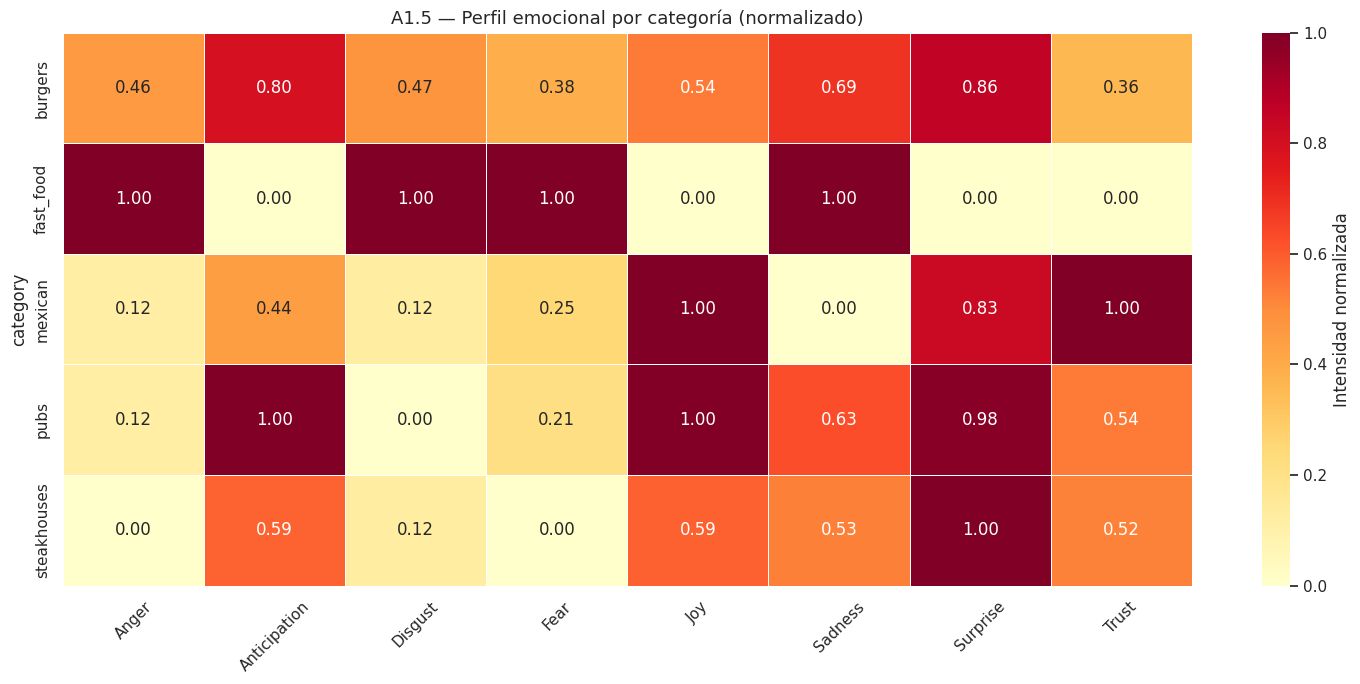

             Surprise   Sadness     Anger     Trust
category                                           
burgers      0.015893  0.009885  0.009436  0.044368
fast_food    0.013017  0.010461  0.011010  0.040715
mexican      0.015796  0.008613  0.008456  0.050887
pubs         0.016294  0.009774  0.008455  0.046193
steakhouses  0.016358  0.009588  0.008114  0.046019


In [5]:
def plot_emotional_profiles(categories, category_dfs, nrc_emotions):
    """
    Calcula y grafica el perfil emocional medio de cada categoría mediante un 
    mapa de calor (heatmap), normalizando los valores para facilitar la comparación.

    Args:
        categories (list<str>): Lista con los nombres de las categorías a analizar.
        category_dfs (dict): Diccionario donde las claves son las categorías (str) y los valores son Polars DataFrames con los datos.
        nrc_emotions (list<str>): Lista con los nombres de las columnas que representan las emociones.
    """
    category_profiles = []

    for cat in categories:
        df = category_dfs[cat]
        profile = (
            df.select(nrc_emotions)
            .mean()
            .with_columns(pl.lit(cat).alias("category"))
        )
        category_profiles.append(profile)

    pd_profiles = (
        pl.concat(category_profiles)
        .to_pandas()
        .set_index("category")
    )

    pd_profiles_norm = (pd_profiles - pd_profiles.min()) / (pd_profiles.max() - pd_profiles.min())
    pd_profiles_norm.columns = [c.replace("nrc_", "").capitalize() for c in pd_profiles_norm.columns]
    pd_profiles.columns      = [c.replace("nrc_", "").capitalize() for c in pd_profiles.columns]

    fig, ax = plt.subplots(figsize=(15, 7))

    sns.heatmap(
        pd_profiles_norm,
        ax=ax,
        cmap="YlOrRd",
        annot=True, fmt=".2f",
        linewidths=0.5,
        vmin=0, vmax=1,
        cbar_kws={"label": "Intensidad normalizada"},
    )
    ax.set_title("A1.5 — Perfil emocional por categoría (normalizado)", fontsize=13)
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print(pd_profiles[["Surprise", "Sadness", "Anger", "Trust"]])
    
plot_emotional_profiles(categories, category_dfs, nrc_emotions)